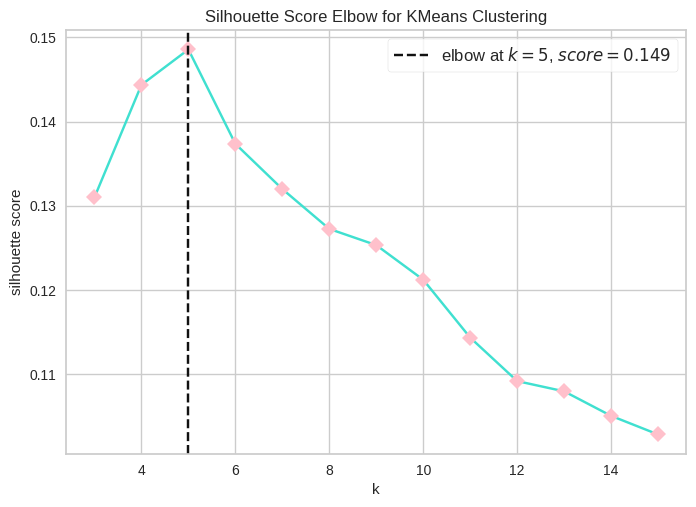

<Axes: title={'center': 'Silhouette Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='silhouette score'>

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

# Load and scale US_births.csv
df_births = pd.read_csv('US_births.csv')
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_births), columns=df_births.columns)

# Elbow Plot (Silhouette Metric)
kmeans_model = KMeans(n_init=10, random_state=42)
elbow_viz = KElbowVisualizer(kmeans_model, k=(3, 16), metric='silhouette', timings=False)
elbow_viz.fit(df_scaled)

# Customize line and marker colors
if elbow_viz.ax.lines:
    line = elbow_viz.ax.lines[0] # Get the first (and usually only) line object
    line.set_color('turquoise')
    line.set_markerfacecolor('pink') # Set the fill color of the markers
    line.set_markeredgecolor('black') # Set the edge color of the markers
    line.set_markersize(8) # Optionally, make markers larger to show the edge better

elbow_viz.show()

Optimal clusters based on Silhouette Score: 5


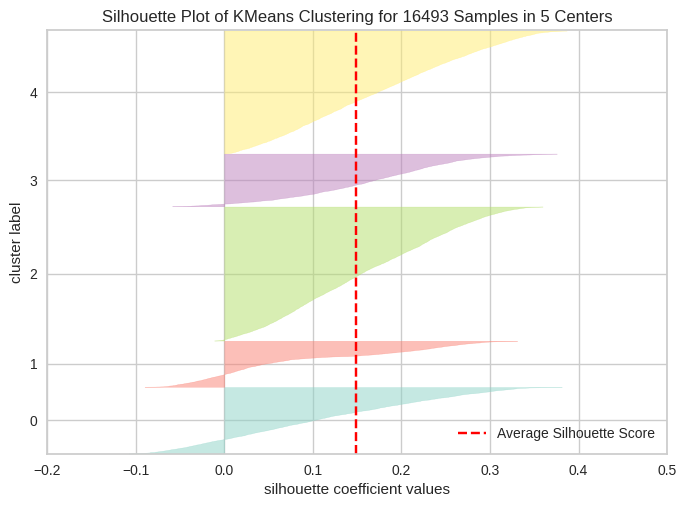

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 16493 Samples in 5 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [17]:
# Silhouette Plot (Using optimal K from elbow)
optimal_k = elbow_viz.elbow_value_
print(f"Optimal clusters based on Silhouette Score: {optimal_k}")

optimal_model = KMeans(n_clusters=optimal_k, n_init=10, random_state=42)
sil_viz = SilhouetteVisualizer(optimal_model, colors='Set3')
sil_viz.fit(df_scaled)
sil_viz.show()

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


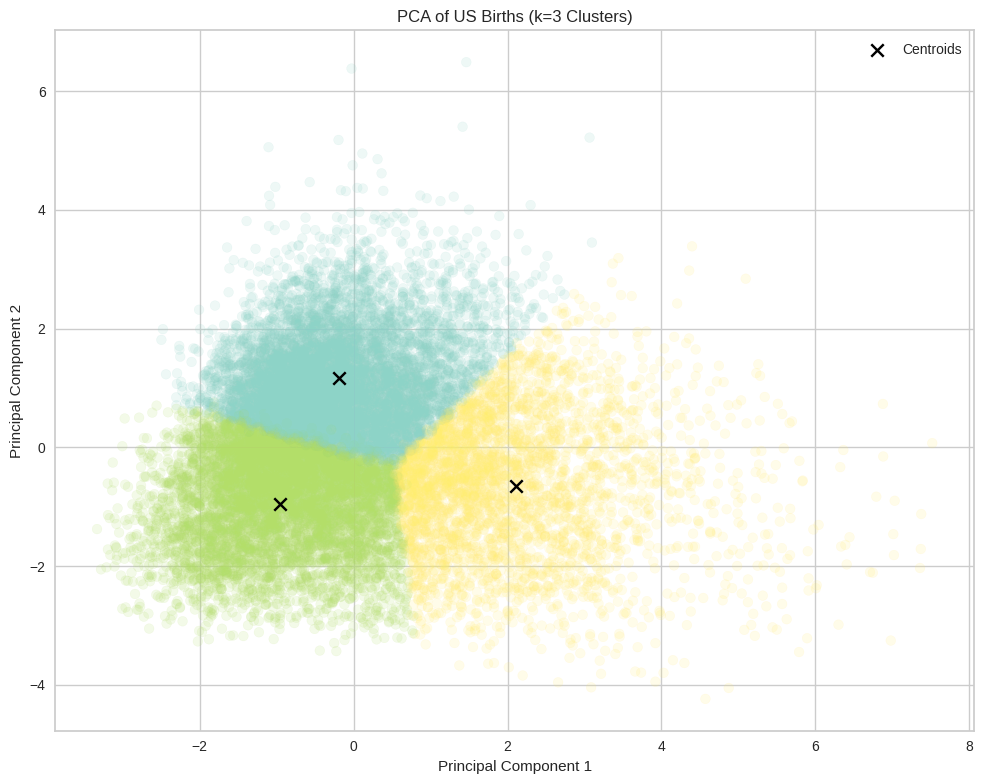

In [16]:
# Fit 3-Cluster Model
kmeans3 = KMeans(n_clusters=3, n_init=10, random_state=42)
cluster_labels = kmeans3.fit_predict(df_scaled)

# PCA Dimensionality Reduction
pca = PCA(n_components=2, random_state=42)
pca_data = pca.fit_transform(df_scaled)

# Convert to DataFrame for plotting
df_pca = pd.DataFrame(pca_data, columns=['PCA1', 'PCA2'])
df_pca['Cluster'] = cluster_labels
pca_centroids = pca.transform(kmeans3.cluster_centers_)

# Scatter Plot
plt.figure(figsize=(10, 8))
plt.scatter(
    df_pca['PCA1'],
    df_pca['PCA2'],
    c=df_pca['Cluster'],
    cmap='Set3',
    alpha=0.15
)

# Plot Centroids
plt.scatter(
    pca_centroids[:, 0],
    pca_centroids[:, 1],
    c='black',
    marker='x',
    s=80,
    label='Centroids'
)

plt.title('PCA of US Births (k=3 Clusters)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.tight_layout()
plt.show()

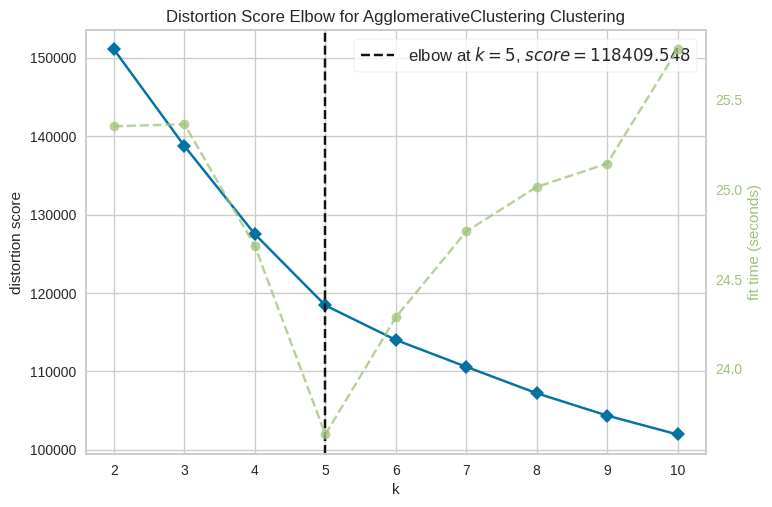

<Axes: title={'center': 'Distortion Score Elbow for AgglomerativeClustering Clustering'}, xlabel='k', ylabel='distortion score'>

In [19]:
from sklearn.cluster import AgglomerativeClustering
from yellowbrick.cluster import KElbowVisualizer

# Elbow Plot for Hierarchical Clustering (Distortion Metric & Timings)
# k=(2, 11) ensures it checks values 2 through 10 inclusively
hc_model = AgglomerativeClustering()
elbow_viz_hc = KElbowVisualizer(hc_model, k=(2, 11), metric='distortion', timings=True)
elbow_viz_hc.fit(df_scaled)
elbow_viz_hc.show()

In [20]:
# Fit Hierarchical Clustering Model (Average Linkage)
optimal_k_hc = elbow_viz_hc.elbow_value_
print(f"Optimal clusters based on Distortion: {optimal_k_hc}")

hc_final = AgglomerativeClustering(n_clusters=optimal_k_hc, linkage='average')
df_births['Cluster'] = hc_final.fit_predict(df_scaled)

# Calculate and Display Median Values (Original Data)
cluster_medians = df_births.groupby('Cluster').median()
display(cluster_medians)

Optimal clusters based on Distortion: 5


,ATTEND,BMI,BWT,FAGE,MAGE,M_HT_IN,PREVIS,PWGT,CESARN,WTGAIN
Cluster,,,,,,,,,,
0,1.0,25.40,3314.0,32.0,30.0,64.0,12.0,148.0,0.0,29.0
1,1.5,27.95,4229.5,38.0,38.5,68.0,10.5,182.5,3.5,77.0
2,1.0,25.10,3183.0,32.5,31.5,64.5,41.5,147.0,0.0,35.0
3,1.0,52.40,3322.0,31.0,26.0,66.0,14.0,360.0,2.0,99.0
4,1.0,28.30,2551.0,37.0,33.0,64.0,5.0,150.0,5.0,14.0


Largest Median Birth Weight (BWT): Cluster 1 has the largest median birth weight at 4229.5 grams.

Smallest Median Pre-Pregnancy Weight (PWGT): Cluster 2 has the smallest median pre-pregnancy weight at 147.0 lbs.